# 🔎 Análise de Consenso entre LLMs

## 1) Setup e Configuração

In [1]:
import sys
from loguru import logger
import pandas as pd
from src.api.schemas.experiment import ExperimentRequest

logger.remove()
logger.add(
    sys.stdout,
    format="<green>{time:HH:mm:ss}</green> | <level>{level: <8}</level> | <level>{message}</level>",
    level="INFO"
)

logger.success("✓ Setup completo")

14:07:47 | SUCCESS  | ✓ Setup completo


In [2]:
import json
from pathlib import Path

experiment = "large_experiment"

# Load JSON from file
config_path = Path(f"../experiments/{experiment}.json")

with open(config_path, "r") as f:
    config_dict = json.load(f)

# Instantiate Pydantic model
EXPERIMENT_CONFIG = ExperimentRequest(**config_dict)

### - Modelos e prompt

In [3]:
DEFAULT_MODELS = EXPERIMENT_CONFIG.models

PROMPT_TYPE = EXPERIMENT_CONFIG.prompt_type

### - Configurações de consenso

In [4]:
consensus_cfg = {
    "threshold": 0.8,
    "strategy": "majority_vote",
    "no_consensus_strategy": "flag_for_review",
}

consensus_threshold = consensus_cfg.get("threshold", 0.8)
consensus_strategy = consensus_cfg.get("strategy", "majority_vote")
no_consensus_strategy = consensus_cfg.get(
    "no_consensus_strategy", "flag_for_review"
)

### - Configurações de dataset

In [5]:
dataset_cfg = EXPERIMENT_CONFIG.dataset_config

dataset_split = dataset_cfg.split
combine_splits = dataset_cfg.combine_splits
sample_size = dataset_cfg.sample_size
random_state = dataset_cfg.random_state

### - Configurações de cache

In [6]:
cache_dir = "C:\\Users\\gabri\\Documents\\GitHub\\llm-annotation\\data\\.cache"

### - Resultados

In [7]:
results_dir = "C:\\Users\\gabri\\Documents\\GitHub\\llm-annotation\\data\\results"

In [8]:
from src.utils.get_latest_results_date import get_latest_results_date

dataset_name = "dblp"
specific_date = "latest"

if specific_date == "latest":
    specific_date = get_latest_results_date(
        results_dir,
        dataset_name
    )
    
results_dir = Path(results_dir)
results_dataset_path = results_dir.joinpath(dataset_name, specific_date)

## 2) Carregar dados

### - Dataset

In [9]:
from src.utils.data_loader import load_hf_dataset

texts, categories, ground_truth = load_hf_dataset(
    dataset_name=dataset_name, 
    cache_dir=cache_dir,
    dataset_global_config=dataset_cfg
)

logger.info(f"Textos: {len(texts)}")
logger.info(f"Categorias: {categories}")
logger.info(f"Ground truth: {'Sim' if ground_truth else 'Não'}")

14:07:48 | Carregando dataset: dblp
14:07:48 | Baixando parquet direto do HuggingFace Hub
14:07:48 | Arquivo baixado em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\.cache\hf\datasets--waashk--dblp\snapshots\89d2ea072c340bf3d2e7060343ba7b52bd21b031\data.parquet
14:07:48 | Dataset carregado: 38128 exemplos
14:07:48 | Categorias extraídas automaticamente: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
14:07:48 | Dataset embaralhado com seed=42
14:07:49 | Coluna de texto: text
14:07:49 | Ground truth carregado da coluna 'label'
14:07:49 | Textos: 38128
14:07:49 | Categorias: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
14:07:49 | Ground truth: Sim


### - Anotações

In [10]:
df_annotations = pd.read_csv(results_dataset_path.joinpath("annotations.csv"))

### - Validando duplicatas

In [11]:
# Quantas duplicatas existem
num_duplicadas = df_annotations.duplicated(subset=["text_id"]).sum()
print(f"Duplicatas encontradas: {num_duplicadas}")

# Ver exemplos
duplicadas = df_annotations[df_annotations.duplicated(subset=["text_id"], keep=False)]
duplicadas.sort_values("text_id")

Duplicatas encontradas: 0


,text_id,text,text_len,deepseek-r1-8b_rep1,deepseek-r1-8b_rep1_conf,deepseek-r1-8b_consensus,deepseek-r1-8b_consensus_score,deepseek-r1-8b_annotation_time_sec,qwen3-8b_rep1,qwen3-8b_rep1_conf,qwen3-8b_consensus,qwen3-8b_consensus_score,qwen3-8b_annotation_time_sec,llama3.1-8b_rep1,llama3.1-8b_rep1_conf,llama3.1-8b_consensus,llama3.1-8b_consensus_score,llama3.1-8b_annotation_time_sec,ground_truth


In [12]:
df_annotations

,text_id,text,text_len,deepseek-r1-8b_rep1,deepseek-r1-8b_rep1_conf,deepseek-r1-8b_consensus,deepseek-r1-8b_consensus_score,deepseek-r1-8b_annotation_time_sec,qwen3-8b_rep1,qwen3-8b_rep1_conf,qwen3-8b_consensus,qwen3-8b_consensus_score,qwen3-8b_annotation_time_sec,llama3.1-8b_rep1,llama3.1-8b_rep1_conf,llama3.1-8b_consensus,llama3.1-8b_consensus_score,llama3.1-8b_annotation_time_sec,ground_truth
0,23c9541b11dba570fd8263b3c1c90973,position based cryptography. we consider what ...,1762,6,0.998627,6,1.0,8.869496,6,1.000000,6,1.0,10.200171,6,0.999998,6,1.0,1.395032,6
1,303ae41199bcc04c32bf41882ef87c69,compare-by-hash: a reasoned analysis. compare-...,642,3,0.998330,3,1.0,12.399741,6,1.000000,6,1.0,19.892030,6,0.999984,6,1.0,0.581068,6
2,c76bf5ea6603fb6468738af9c1453672,clairvoyant scheduling of random walks. two in...,663,9,0.998269,9,1.0,13.045270,9,1.000000,9,1.0,20.569628,9,0.995840,9,1.0,1.394809,9
3,ffbfb7ecf1de8900c5dceadea152b947,a hybrid fingerprint matcher. we describe a hy...,841,6,0.995699,6,1.0,15.935235,6,1.000000,6,1.0,20.820029,6,0.794437,6,1.0,1.394021,0
4,e645b225c6e7687a5880294e051edc2a,requirements gathering with diverse user group...,851,3,0.995803,3,1.0,20.419789,3,1.000000,3,1.0,21.685089,3,0.997535,3,1.0,1.587652,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38048,af347e4e2c7a1db6792d41c0e4d0547c,a framework for password-based authenticated k...,1010,6,0.993999,6,1.0,8.368330,6,1.000000,6,1.0,8.234457,6,0.999997,6,1.0,0.239004,6
38049,551174b0b08a2960a1e3534a69961616,tree-based clustering for gene expression data...,630,5,0.998177,5,1.0,8.416866,5,1.000000,5,1.0,8.292397,2,0.070053,2,1.0,0.225241,9
38050,90b815461494bb308eb49678f1c55376,exploring iterative and parallel human computa...,521,9,0.985478,9,1.0,27.392421,1,0.999998,1,1.0,43.498468,1,0.922152,1,1.0,0.229910,4
38051,3f756d2dc7dfa0b0550382a6efa00c0e,quasiconvex analysis of backtracking algorithm...,848,9,0.998443,9,1.0,7.908497,9,1.000000,9,1.0,7.810058,9,0.990461,9,1.0,0.236317,9


### - Métricas

In [13]:
df_metrics = pd.read_csv(results_dataset_path.joinpath("model_metrics.csv"))

df_metrics

,model,accuracy,f1_macro,precision_macro,recall_macro,coverage,error_rate,invalid_predictions_rate
0,deepseek-r1-8b,0.625890,0.602773,0.627969,0.634152,0.999790,0.374110,0.000210
1,qwen3-8b,0.633922,0.600134,0.636047,0.639366,0.999974,0.366078,0.000026
2,llama3.1-8b,0.599480,0.593902,0.621202,0.663633,1.000000,0.400520,0.000000


## 3) Calcular Consenso

In [14]:
from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

# Inicializar calculador
consensus_calculator = ConsensusCalculator(
    consensus_threshold=consensus_threshold,
    default_strategy=consensus_strategy
)

analyzer = ConsensusEvaluator(
    categories=categories, 
    calculator=consensus_calculator, 
    output_dir=results_dataset_path
)

df_with_consensus = analyzer.compute_consensus(df_annotations)

14:07:50 | Executando cálculo de consenso interno...
14:07:50 | Calculando consenso...
14:07:50 | Consenso calculado:
14:07:50 |   Alto (≥80%): 27060 (71.1%)
14:07:50 |   Médio (60-80%): 10178 (26.7%)
14:07:50 |   Baixo (<60%): 815 (2.1%)
14:07:50 |   Problemáticos: 815 (2.1%)
14:07:50 |   Itens que precisam de revisão: 0 (0.0%)
14:07:50 | Cálculo de consenso finalizado.


In [15]:
df_with_consensus

,text_id,text,text_len,deepseek-r1-8b_rep1,deepseek-r1-8b_rep1_conf,deepseek-r1-8b_consensus,deepseek-r1-8b_consensus_score,deepseek-r1-8b_annotation_time_sec,qwen3-8b_rep1,qwen3-8b_rep1_conf,...,ground_truth,all_annotations,unique_annotations,most_common_annotation,most_common_count,consensus_score,consensus_level,is_problematic,resolved_annotation,needs_review
0,23c9541b11dba570fd8263b3c1c90973,position based cryptography. we consider what ...,1762,6,0.998627,6,1.0,8.869496,6,1.000000,...,6,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
1,303ae41199bcc04c32bf41882ef87c69,compare-by-hash: a reasoned analysis. compare-...,642,3,0.998330,3,1.0,12.399741,6,1.000000,...,6,"[3, 6, 6]",2,6,2,0.666667,medium,False,6,False
2,c76bf5ea6603fb6468738af9c1453672,clairvoyant scheduling of random walks. two in...,663,9,0.998269,9,1.0,13.045270,9,1.000000,...,9,"[9, 9, 9]",1,9,3,1.000000,high,False,9,False
3,ffbfb7ecf1de8900c5dceadea152b947,a hybrid fingerprint matcher. we describe a hy...,841,6,0.995699,6,1.0,15.935235,6,1.000000,...,0,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
4,e645b225c6e7687a5880294e051edc2a,requirements gathering with diverse user group...,851,3,0.995803,3,1.0,20.419789,3,1.000000,...,4,"[3, 3, 3]",1,3,3,1.000000,high,False,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38048,af347e4e2c7a1db6792d41c0e4d0547c,a framework for password-based authenticated k...,1010,6,0.993999,6,1.0,8.368330,6,1.000000,...,6,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
38049,551174b0b08a2960a1e3534a69961616,tree-based clustering for gene expression data...,630,5,0.998177,5,1.0,8.416866,5,1.000000,...,9,"[5, 5, 2]",2,5,2,0.666667,medium,False,5,False
38050,90b815461494bb308eb49678f1c55376,exploring iterative and parallel human computa...,521,9,0.985478,9,1.0,27.392421,1,0.999998,...,4,"[9, 1, 1]",2,1,2,0.666667,medium,False,1,False
38051,3f756d2dc7dfa0b0550382a6efa00c0e,quasiconvex analysis of backtracking algorithm...,848,9,0.998443,9,1.0,7.908497,9,1.000000,...,9,"[9, 9, 9]",1,9,3,1.000000,high,False,9,False


### - Removendo instancias problemáticas e invalidas

#### -> Invalidas

##### Removendo do Ground-Truth

In [16]:
df_invalid_gt = df_with_consensus.loc[
    df_with_consensus["resolved_annotation"] == -1 
]

df_with_consensus = df_with_consensus[
        ~df_with_consensus["text_id"].isin(df_invalid_gt["text_id"])
    ].reset_index(drop=True)

In [17]:
df_with_consensus

,text_id,text,text_len,deepseek-r1-8b_rep1,deepseek-r1-8b_rep1_conf,deepseek-r1-8b_consensus,deepseek-r1-8b_consensus_score,deepseek-r1-8b_annotation_time_sec,qwen3-8b_rep1,qwen3-8b_rep1_conf,...,ground_truth,all_annotations,unique_annotations,most_common_annotation,most_common_count,consensus_score,consensus_level,is_problematic,resolved_annotation,needs_review
0,23c9541b11dba570fd8263b3c1c90973,position based cryptography. we consider what ...,1762,6,0.998627,6,1.0,8.869496,6,1.000000,...,6,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
1,303ae41199bcc04c32bf41882ef87c69,compare-by-hash: a reasoned analysis. compare-...,642,3,0.998330,3,1.0,12.399741,6,1.000000,...,6,"[3, 6, 6]",2,6,2,0.666667,medium,False,6,False
2,c76bf5ea6603fb6468738af9c1453672,clairvoyant scheduling of random walks. two in...,663,9,0.998269,9,1.0,13.045270,9,1.000000,...,9,"[9, 9, 9]",1,9,3,1.000000,high,False,9,False
3,ffbfb7ecf1de8900c5dceadea152b947,a hybrid fingerprint matcher. we describe a hy...,841,6,0.995699,6,1.0,15.935235,6,1.000000,...,0,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
4,e645b225c6e7687a5880294e051edc2a,requirements gathering with diverse user group...,851,3,0.995803,3,1.0,20.419789,3,1.000000,...,4,"[3, 3, 3]",1,3,3,1.000000,high,False,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38043,af347e4e2c7a1db6792d41c0e4d0547c,a framework for password-based authenticated k...,1010,6,0.993999,6,1.0,8.368330,6,1.000000,...,6,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
38044,551174b0b08a2960a1e3534a69961616,tree-based clustering for gene expression data...,630,5,0.998177,5,1.0,8.416866,5,1.000000,...,9,"[5, 5, 2]",2,5,2,0.666667,medium,False,5,False
38045,90b815461494bb308eb49678f1c55376,exploring iterative and parallel human computa...,521,9,0.985478,9,1.0,27.392421,1,0.999998,...,4,"[9, 1, 1]",2,1,2,0.666667,medium,False,1,False
38046,3f756d2dc7dfa0b0550382a6efa00c0e,quasiconvex analysis of backtracking algorithm...,848,9,0.998443,9,1.0,7.908497,9,1.000000,...,9,"[9, 9, 9]",1,9,3,1.000000,high,False,9,False


##### Removendo da anotação

In [18]:
df_invalid = df_with_consensus.loc[
    df_with_consensus["resolved_annotation"] == -1 
]

df_with_consensus = df_with_consensus[
        ~df_with_consensus["text_id"].isin(df_invalid["text_id"])
    ].reset_index(drop=True)

In [19]:
df_with_consensus

,text_id,text,text_len,deepseek-r1-8b_rep1,deepseek-r1-8b_rep1_conf,deepseek-r1-8b_consensus,deepseek-r1-8b_consensus_score,deepseek-r1-8b_annotation_time_sec,qwen3-8b_rep1,qwen3-8b_rep1_conf,...,ground_truth,all_annotations,unique_annotations,most_common_annotation,most_common_count,consensus_score,consensus_level,is_problematic,resolved_annotation,needs_review
0,23c9541b11dba570fd8263b3c1c90973,position based cryptography. we consider what ...,1762,6,0.998627,6,1.0,8.869496,6,1.000000,...,6,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
1,303ae41199bcc04c32bf41882ef87c69,compare-by-hash: a reasoned analysis. compare-...,642,3,0.998330,3,1.0,12.399741,6,1.000000,...,6,"[3, 6, 6]",2,6,2,0.666667,medium,False,6,False
2,c76bf5ea6603fb6468738af9c1453672,clairvoyant scheduling of random walks. two in...,663,9,0.998269,9,1.0,13.045270,9,1.000000,...,9,"[9, 9, 9]",1,9,3,1.000000,high,False,9,False
3,ffbfb7ecf1de8900c5dceadea152b947,a hybrid fingerprint matcher. we describe a hy...,841,6,0.995699,6,1.0,15.935235,6,1.000000,...,0,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
4,e645b225c6e7687a5880294e051edc2a,requirements gathering with diverse user group...,851,3,0.995803,3,1.0,20.419789,3,1.000000,...,4,"[3, 3, 3]",1,3,3,1.000000,high,False,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38043,af347e4e2c7a1db6792d41c0e4d0547c,a framework for password-based authenticated k...,1010,6,0.993999,6,1.0,8.368330,6,1.000000,...,6,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
38044,551174b0b08a2960a1e3534a69961616,tree-based clustering for gene expression data...,630,5,0.998177,5,1.0,8.416866,5,1.000000,...,9,"[5, 5, 2]",2,5,2,0.666667,medium,False,5,False
38045,90b815461494bb308eb49678f1c55376,exploring iterative and parallel human computa...,521,9,0.985478,9,1.0,27.392421,1,0.999998,...,4,"[9, 1, 1]",2,1,2,0.666667,medium,False,1,False
38046,3f756d2dc7dfa0b0550382a6efa00c0e,quasiconvex analysis of backtracking algorithm...,848,9,0.998443,9,1.0,7.908497,9,1.000000,...,9,"[9, 9, 9]",1,9,3,1.000000,high,False,9,False


#### -> Problematicas

In [20]:
problematica_cases_path = results_dataset_path.joinpath("consensus", "problematic_cases.csv")
df_problematic = None

##### Removendo da anotação

In [21]:
if problematica_cases_path.exists():
    df_problematic = pd.read_csv(problematica_cases_path)
    df_with_consensus = df_with_consensus[
        ~df_with_consensus["text_id"].isin(df_problematic["text_id"])
    ].reset_index(drop=True)

In [22]:
df_with_consensus

,text_id,text,text_len,deepseek-r1-8b_rep1,deepseek-r1-8b_rep1_conf,deepseek-r1-8b_consensus,deepseek-r1-8b_consensus_score,deepseek-r1-8b_annotation_time_sec,qwen3-8b_rep1,qwen3-8b_rep1_conf,...,ground_truth,all_annotations,unique_annotations,most_common_annotation,most_common_count,consensus_score,consensus_level,is_problematic,resolved_annotation,needs_review
0,23c9541b11dba570fd8263b3c1c90973,position based cryptography. we consider what ...,1762,6,0.998627,6,1.0,8.869496,6,1.000000,...,6,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
1,303ae41199bcc04c32bf41882ef87c69,compare-by-hash: a reasoned analysis. compare-...,642,3,0.998330,3,1.0,12.399741,6,1.000000,...,6,"[3, 6, 6]",2,6,2,0.666667,medium,False,6,False
2,c76bf5ea6603fb6468738af9c1453672,clairvoyant scheduling of random walks. two in...,663,9,0.998269,9,1.0,13.045270,9,1.000000,...,9,"[9, 9, 9]",1,9,3,1.000000,high,False,9,False
3,ffbfb7ecf1de8900c5dceadea152b947,a hybrid fingerprint matcher. we describe a hy...,841,6,0.995699,6,1.0,15.935235,6,1.000000,...,0,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
4,e645b225c6e7687a5880294e051edc2a,requirements gathering with diverse user group...,851,3,0.995803,3,1.0,20.419789,3,1.000000,...,4,"[3, 3, 3]",1,3,3,1.000000,high,False,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38043,af347e4e2c7a1db6792d41c0e4d0547c,a framework for password-based authenticated k...,1010,6,0.993999,6,1.0,8.368330,6,1.000000,...,6,"[6, 6, 6]",1,6,3,1.000000,high,False,6,False
38044,551174b0b08a2960a1e3534a69961616,tree-based clustering for gene expression data...,630,5,0.998177,5,1.0,8.416866,5,1.000000,...,9,"[5, 5, 2]",2,5,2,0.666667,medium,False,5,False
38045,90b815461494bb308eb49678f1c55376,exploring iterative and parallel human computa...,521,9,0.985478,9,1.0,27.392421,1,0.999998,...,4,"[9, 1, 1]",2,1,2,0.666667,medium,False,1,False
38046,3f756d2dc7dfa0b0550382a6efa00c0e,quasiconvex analysis of backtracking algorithm...,848,9,0.998443,9,1.0,7.908497,9,1.000000,...,9,"[9, 9, 9]",1,9,3,1.000000,high,False,9,False


### - Estatisticas

In [23]:
logger.info("\n📊 Estatísticas de Consenso:")
logger.info(f"  Média: {df_with_consensus['consensus_score'].mean():.2%}")
logger.info(f"  Mediana: {df_with_consensus['consensus_score'].median():.2%}")
logger.info(f"  Desvio padrão: {df_with_consensus['consensus_score'].std():.2%}")

14:07:51 | 
📊 Estatísticas de Consenso:
14:07:51 |   Média: 89.66%
14:07:51 |   Mediana: 100.00%
14:07:51 |   Desvio padrão: 16.88%


### - Distribuição por nível

In [24]:
# Distribuição por nível
levels = df_with_consensus['consensus_level'].value_counts()
logger.info("Distribuição por nível:")
for level, count in levels.items():
    logger.info(f"  {level}: {count} ({count/len(df_with_consensus):.1%})")

14:07:51 | Distribuição por nível:
14:07:51 |   high: 27060 (71.1%)
14:07:51 |   medium: 10178 (26.8%)
14:07:51 |   low: 810 (2.1%)


### - Visualizar consenso

In [25]:
from src.llm_annotation_system.consensus.consensus_visualizer import ConsensusVisualizer

visualizer = ConsensusVisualizer(output_dir=results_dataset_path)

In [26]:
visualizer.plot_score_and_levels(
    df_with_consensus=df_with_consensus,
    levels=levels
)

✓ Gráfico salvo: score_and_levels.html


## 4) Análise Detalhada de Consenso

### - Gerando Report

In [27]:
# Gerar relatório
report = analyzer.generate_consensus_report(
    df=df_with_consensus
)

logger.success("✓ Relatório gerado")

14:07:52 | Gerando relatório completo de consenso...
14:07:53 | Fleiss' Kappa: 0.766 (Bom)
14:07:54 | Casos problemáticos: 810
14:07:54 | Relatório de consenso gerado com sucesso.
14:07:54 | ✓ Relatório gerado


### - Pairwise_agreement

In [28]:
# logger.info("\n📊 Gerando heatmap de concordância...")
# visualizer.plot_agreement_heatmap(
#     agreement_df=report['pairwise_agreement'],
#     title='Matriz de Concordância entre Modelos',
# )

### - Cohens Kappa

In [29]:
logger.info("\n📊 Gerando heatmap de Cohens_Kappa...")
visualizer.plot_kappa_heatmap(
    kappa_df=report['cohens_kappa']
)

14:07:54 | 
📊 Gerando heatmap de Cohens_Kappa...


✓ Heatmap salvo: kappa_heatmap.html


### - Casos problemáticos

In [30]:
# Casos problemáticos
problematic = report.get('problematic_cases')
if problematic is not None and len(problematic) > 0:
    logger.warning(f"\n⚠️  {len(problematic)} casos problemáticos identificados")
    display(problematic)
else:
    logger.success("\n✓ Nenhum caso problemático identificado")

14:07:55 | 
⚠️  810 casos problemáticos identificados


,text_id,text,consensus_score,annotations,entropy
0,b1a25035d6000a92234ebe981f0b9b16,network motif discovery using subgraph enumera...,0.333333,"{9: 1, 5: 1, 2: 1}",1.584963
1,0164a450f010d8cdc6dfc446f36e6004,voting and political information gathering on ...,0.333333,"{3: 1, 5: 1, 4: 1}",1.584963
2,7bf40891c3cde3d5aaa32f6b3ea3b9f0,map approach to learning sparse gaussian marko...,0.333333,"{9: 1, 5: 1, 2: 1}",1.584963
3,dbb20fd7492ee1552f7c1ff557003611,offline cursive word recognition using continu...,0.333333,"{0: 1, 7: 1, 1: 1}",1.584963
4,f61a4da6de96b5fe19fe18993c99414b,multitouch and surface computing. natural user...,0.333333,"{9: 1, 3: 1, 4: 1}",1.584963
...,...,...,...,...,...
805,480c4639d0420d2429258f54b1bab594,the effects of background music on using a poc...,0.333333,"{9: 1, 7: 1, 3: 1}",1.584963
806,245232ff86de8c9e1fa171eae7913b8e,performance optimization of latency insensitiv...,0.333333,"{9: 1, 7: 1, 3: 1}",1.584963
807,70bd9197547c3606f20b9a327e46a31f,fingersense: augmenting expressiveness to phys...,0.333333,"{9: 1, 3: 1, 8: 1}",1.584963
808,182d44059534606ebc0224a39530b2a8,practical scalability of wavelength routing sw...,0.333333,"{9: 1, 3: 1, 7: 1}",1.584963


## 5) Validação com Ground Truth

In [31]:
accuracy, cls_report, cm = analyzer.evaluate_ground_truth(
    df_with_consensus=df_with_consensus
)

visualizer.plot_confusion_matrix(
    cm=cm,
    categories=categories
)

14:07:55 | 
🎯 Accuracy: 63.56%
14:07:55 | 
Classification Report:


{'0': {'precision': 0.795353203473363, 'recall': 0.792192613370734, 'f1-score': 0.7937697622672444, 'support': 4278.0}, '1': {'precision': 0.7853721444362565, 'recall': 0.9511378848728246, 'f1-score': 0.860343087790111, 'support': 4482.0}, '2': {'precision': 0.6230706742485784, 'recall': 0.5154569892473119, 'f1-score': 0.5641780066200809, 'support': 1488.0}, '3': {'precision': 0.370692872247792, 'recall': 0.9385826771653544, 'f1-score': 0.5314785090065989, 'support': 3175.0}, '4': {'precision': 0.5704125177809388, 'recall': 0.08133874239350913, 'f1-score': 0.1423752884786082, 'support': 4930.0}, '5': {'precision': 0.728595890410959, 'recall': 0.63825, 'f1-score': 0.6804371002132196, 'support': 4000.0}, '6': {'precision': 0.49162303664921464, 'recall': 0.6640735502121641, 'f1-score': 0.5649819494584838, 'support': 1414.0}, '7': {'precision': 0.5936708860759494, 'recall': 0.445253164556962, 'f1-score': 0.5088607594936709, 'support': 3160.0}, '8': {'precision': 0.7686053783614759, 'recall

✓ Matriz de confusão salva em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\dblp\2026-04-09_14-05-21\graphics\confusion_matrix.html


## 6) Exportar Resultados

In [32]:
import json

# Criar diretório
results_dir = results_dataset_path.joinpath("summary")
results_dir.mkdir(parents=True, exist_ok=True)

# Salvar CSVs
df_with_consensus.to_csv(results_dir / 'dataset_anotado_completo.csv', index=False)
logger.info(f"✓ Salvos: {len(df_with_consensus)} registros")

# Alta confiança
high_conf = df_with_consensus[df_with_consensus['consensus_score'] >= 0.8]
high_conf.to_csv(results_dir / 'alta_confianca.csv', index=False)
logger.info(f"✓ Alta confiança: {len(high_conf)} registros")

# Necessita revisão
low_conf = df_with_consensus[df_with_consensus['consensus_score'] < 0.8]
low_conf.to_csv(results_dir / 'necessita_revisao.csv', index=False)
logger.info(f"✓ Necessita revisão: {len(low_conf)} registros")

# Sumário JSON
summary = {
    'dataset': {
        'name': dataset_name,
        'total_texts': len(texts),
        'categories': categories,
        'has_ground_truth': ground_truth is not None
    },
    'config': {
        'models': DEFAULT_MODELS,
        'prompt_type': PROMPT_TYPE,
        'total_models': len(DEFAULT_MODELS),
        'use_alternative_params': False,
        'num_repetitions': 1,
        'total_annotations': len(texts) * len(DEFAULT_MODELS) * 1
    },
    'results': {
        'consensus_mean': float(df_with_consensus['consensus_score'].mean()),
        'consensus_median': float(df_with_consensus['consensus_score'].median()),
        'high_consensus': int((df_with_consensus['consensus_level'] == 'high').sum()),
        'medium_consensus': int((df_with_consensus['consensus_level'] == 'medium').sum()),
        'low_consensus': int((df_with_consensus['consensus_level'] == 'low').sum()),
    },
    'metrics': {
        'fleiss_kappa': float(report['fleiss_kappa']),
        'fleiss_interpretation': report['fleiss_interpretation']
    }
}

if ground_truth:
    summary['validation'] = {
        'classification_report': cls_report
    }

with open(results_dir / 'sumario_experimento.json', 'w') as f:
    json.dump(summary, f, indent=2)

logger.success("\n✓ Resultados exportados com sucesso!")

14:07:55 | ✓ Salvos: 38048 registros
14:07:56 | ✓ Alta confiança: 27060 registros
14:07:56 | ✓ Necessita revisão: 10988 registros
14:07:56 | 
✓ Resultados exportados com sucesso!


## 7) Análise de Confiança das Anotações

### - Configuração

In [33]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

CONF_COLS  = [f"{m}_rep1_conf"  for m in DEFAULT_MODELS]
LABEL_COLS = [f"{m}_consensus"  for m in DEFAULT_MODELS]
N_BINS     = 10
CONF_THRESH = 0.9
CONF_BINS  = np.linspace(0, 1, N_BINS + 1)

COLORS = {
    "deepseek-r1-8b": "#e45c3a",
    "qwen3-8b":       "#3a8fe4",
    "llama3.1-8b":    "#3ae47c",
}

logger.success("✓ Configuração de confiança pronta")

14:07:56 | ✓ Configuração de confiança pronta


### - 7.1) Distribuição de Confiança por Modelo

In [34]:
# fig = go.Figure()
# for model in DEFAULT_MODELS:
#     fig.add_trace(go.Histogram(
#         x=df_annotations[f"{model}_rep1_conf"],
#         name=model,
#         opacity=0.7,
#         nbinsx=40,
#         marker_color=COLORS.get(model),
#     ))

# fig.update_layout(
#     barmode="overlay",
#     title="Distribuição de Confiança por Modelo",
#     xaxis_title="Confiança",
#     yaxis_title="Frequência",
#     legend_title="Modelo",
# )
# fig.show()

# logger.info("\n📊 Estatísticas de Confiança por Modelo:")
# print(df_annotations[CONF_COLS].describe().round(4).to_string())

### - 7.2) Confiança Média por Classe (Heatmap)

In [35]:
rows = []

for model in DEFAULT_MODELS:
    label_col = f"{model}_consensus"
    conf_col  = f"{model}_rep1_conf"

    # 👇 filtra removendo classe -1
    df_tmp = df_annotations[df_annotations[label_col] != -1]

    grouped = df_tmp.groupby(label_col)[conf_col].mean().reset_index()
    grouped.columns = ["class", "mean_conf"]
    grouped["model"] = model

    rows.append(grouped)

df_conf_class = pd.concat(rows).pivot(index="model", columns="class", values="mean_conf")

fig = go.Figure(go.Heatmap(
    z=df_conf_class.values,
    x=[str(c) for c in df_conf_class.columns],
    y=df_conf_class.index.tolist(),
    colorscale="Reds",
    zmin=0.5, zmax=1.0,
    text=df_conf_class.values.round(3),
    texttemplate="%{text}",
))

fig.update_layout(
    title="Confiança Média por Modelo × Classe",
    xaxis_title="Classe Predita",
    yaxis_title="Modelo",
)

fig.show()

### - 7.3) Diagrama de Calibração (Reliability Diagram)

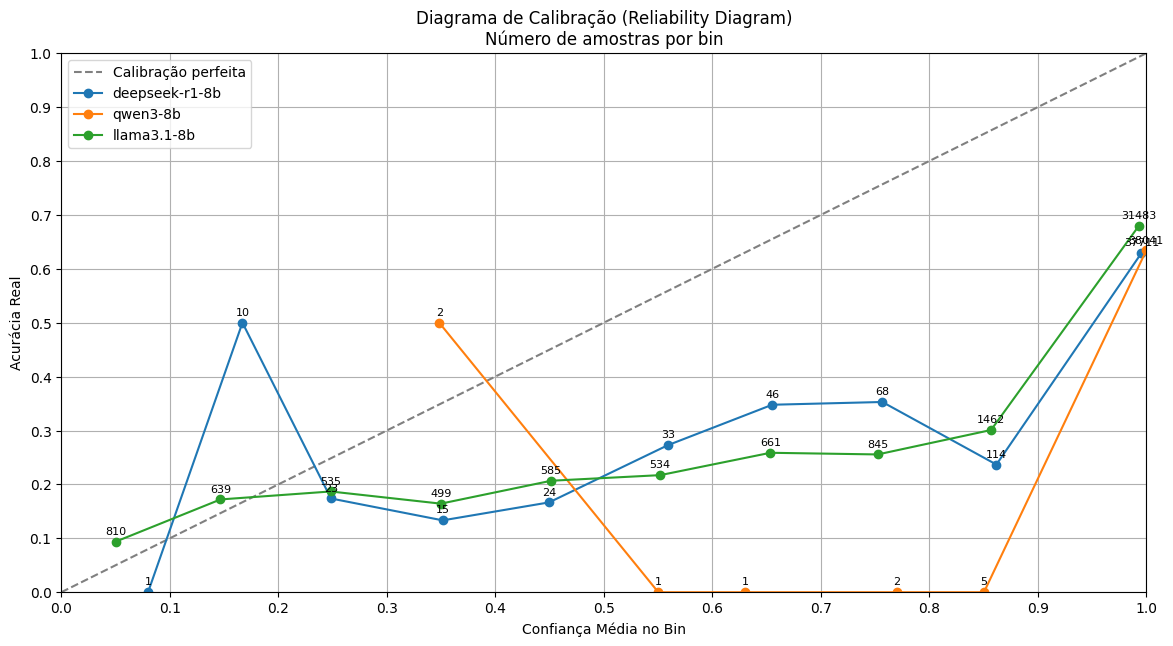

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Linha de calibração perfeita
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibração perfeita")

for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"

    df_cal = df_annotations[[conf_col, label_col, "ground_truth"]].dropna().copy()
    df_cal["bin"] = pd.cut(df_cal[conf_col], bins=CONF_BINS, labels=False, include_lowest=True)
    df_cal["correct"] = (df_cal[label_col] == df_cal["ground_truth"]).astype(int)

    cal = df_cal.groupby("bin").agg(
        mean_conf=(conf_col, "mean"),
        accuracy=("correct", "mean"),
        count=("correct", "count"),
    ).reset_index().dropna()

    # Plot linha + pontos
    plt.plot(cal["mean_conf"], cal["accuracy"], marker="o", label=model)

    # Adicionar texto (count) acima dos pontos
    for i, row in cal.iterrows():
        plt.text(
            row["mean_conf"],
            row["accuracy"] + 0.01,
            str(int(row["count"])),
            fontsize=8,
            ha="center",
            va="bottom"
        )

plt.title("Diagrama de Calibração (Reliability Diagram)\nNúmero de amostras por bin")
plt.xlabel("Confiança Média no Bin")
plt.ylabel("Acurácia Real")

# Expandir limite pra não cortar texto
plt.xlim(0, 1)
plt.ylim(0, 1)

# 👇 divisão de 0.1 em 0.1
plt.xticks(np.arange(0, 1.01, 0.1))
plt.yticks(np.arange(0, 1.01, 0.1))

plt.grid(True)
plt.legend()

plt.show()

In [37]:
# fig = go.Figure()
# fig.add_trace(go.Scatter(
#     x=[0, 1], y=[0, 1],
#     mode="lines", line=dict(dash="dash", color="gray"),
#     name="Calibração perfeita"
# ))

# for model in DEFAULT_MODELS:
#     conf_col  = f"{model}_rep1_conf"
#     label_col = f"{model}_consensus"

#     df_cal = df_annotations[[conf_col, label_col, "ground_truth"]].dropna().copy()
#     df_cal["bin"] = pd.cut(df_cal[conf_col], bins=CONF_BINS, labels=False, include_lowest=True)
#     df_cal["correct"] = (df_cal[label_col] == df_cal["ground_truth"]).astype(int)

#     cal = df_cal.groupby("bin").agg(
#         mean_conf=(conf_col, "mean"),
#         accuracy=("correct", "mean"),
#         count=(conf_col, "count"),
#     ).reset_index()

#     fig.add_trace(go.Scatter(
#         x=cal["mean_conf"],
#         y=cal["accuracy"],
#         mode="lines+markers+text",
#         name=model,
#         text=cal["count"],  # 👈 número de amostras
#         textposition="top center",  # 👈 posição do texto
#         marker=dict(color=COLORS.get(model)),
#         line=dict(color=COLORS.get(model)),
#     ))

# fig.update_layout(
#     title="Diagrama de Calibração (Reliability Diagram)<br><sup>Número de amostras por bin</sup>",
#     xaxis_title="Confiança Média no Bin",
#     yaxis_title="Acurácia Real",
#     xaxis=dict(range=[0, 1]),
#     yaxis=dict(range=[0, 1]),
#     width=1400,
#     height=600,
# )

# fig.show()

### - 7.4) Distribuição de Acertos/Erros vs Confiança

In [38]:
import pandas as pd

rows = []

CONF_THRESHOLD = 0.9

for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"

    df_tmp = df_annotations[[conf_col, label_col, "ground_truth"]].dropna().copy()

    df_tmp["correct"] = df_tmp[label_col] == df_tmp["ground_truth"]
    df_tmp["high_conf"] = df_tmp[conf_col] >= CONF_THRESHOLD

    counts = {
        "model": model,
        "Correct & High": ((df_tmp["correct"]) & (df_tmp["high_conf"])).sum(),
        "Correct & Low":  ((df_tmp["correct"]) & (~df_tmp["high_conf"])).sum(),
        "Wrong & High":   ((~df_tmp["correct"]) & (df_tmp["high_conf"])).sum(),
        "Wrong & Low":    ((~df_tmp["correct"]) & (~df_tmp["high_conf"])).sum(),
    }

    rows.append(counts)

df_conf_matrix = pd.DataFrame(rows)

In [39]:
import plotly.graph_objects as go

categories = ["Correct & High", "Correct & Low", "Wrong & High", "Wrong & Low"]

fig = go.Figure()

for cat in categories:
    fig.add_trace(go.Bar(
        x=df_conf_matrix["model"],
        y=df_conf_matrix[cat],
        name=cat
    ))

fig.update_layout(
    barmode="stack",
    title=f"Distribuição de Acertos/Erros vs Confiança (threshold={CONF_THRESHOLD})",
    xaxis_title="Modelo",
    yaxis_title="Quantidade de textos",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

### - 7.6) Expected Calibration Error (ECE)

In [40]:
logger.info("\n📐 Expected Calibration Error (ECE) — menor é melhor:")
ece_rows = []
for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"
    df_m = df_annotations[[conf_col, label_col, "ground_truth"]].dropna().copy()
    df_m["bin"] = pd.cut(df_m[conf_col], bins=CONF_BINS, labels=False, include_lowest=True)
    df_m["correct"] = (df_m[label_col] == df_m["ground_truth"]).astype(int)

    ece = 0.0
    n = len(df_m)
    for b in range(N_BINS):
        mask = df_m["bin"] == b
        if mask.sum() == 0:
            continue
        acc  = df_m.loc[mask, "correct"].mean()
        conf = df_m.loc[mask, conf_col].mean()
        ece += (mask.sum() / n) * abs(acc - conf)

    ece_rows.append({"Modelo": model, "ECE": round(ece, 4)})
    logger.info(f"  {model:20s}: ECE = {ece:.4f}")

df_ece = pd.DataFrame(ece_rows)
import plotly.graph_objects as go

df_ece = pd.DataFrame(ece_rows).sort_values("ECE")

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_ece["Modelo"],
    y=df_ece["ECE"],
    text=df_ece["ECE"].round(4),
    textposition="auto"
))

fig.update_layout(
    title="Expected Calibration Error (ECE) por Modelo",
    xaxis_title="Modelo",
    yaxis_title="ECE (↓ melhor)",
    template="plotly_white",
    width=800,
    height=500
)

fig.show()

14:07:57 | 
📐 Expected Calibration Error (ECE) — menor é melhor:
14:07:57 |   deepseek-r1-8b      : ECE = 0.3668
14:07:57 |   qwen3-8b            : ECE = 0.3660
14:07:57 |   llama3.1-8b         : ECE = 0.3120


### 7.7) BBS score

In [41]:
from src.utils.compute_bbs import compute_bbs

logger.info("\n📐 Balanced Brier Score (BBS) — menor é melhor:")

bbs_results = []

for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"

    bbs = compute_bbs(df_annotations, conf_col, label_col)

    bbs_results.append({
        "model": model,
        "BBS": bbs
    })

    # 👇 log no mesmo padrão do ECE
    logger.info(f"  {model:20s}: BBS = {bbs:.4f}")

df_bbs = pd.DataFrame(bbs_results).sort_values("BBS")

14:07:57 | 
📐 Balanced Brier Score (BBS) — menor é melhor:
14:07:57 |   deepseek-r1-8b      : BBS = 0.4940
14:07:57 |   qwen3-8b            : BBS = 0.5000
14:07:57 |   llama3.1-8b         : BBS = 0.4682


In [42]:
import plotly.graph_objects as go

df_bbs = pd.DataFrame(bbs_results).sort_values("BBS")

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_bbs["model"],
    y=df_bbs["BBS"],
    text=df_bbs["BBS"].round(4),
    textposition="auto"
))

fig.update_layout(
    title="Balanced Brier Score (BBS) por Modelo",
    xaxis_title="Modelo",
    yaxis_title="BBS (↓ melhor)",
    template="plotly_white",
    width=800,
    height=500
)

fig.show()

### - Extra: por BIN

In [43]:
from src.utils.compute_bbs import compute_bbs_per_bin

fig = go.Figure()

for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"

    df_bbs_bin = compute_bbs_per_bin(df_annotations, conf_col, label_col)

    fig.add_trace(go.Scatter(
        x=df_bbs_bin["mean_conf"],
        y=df_bbs_bin["bbs_bin"],
        mode="lines+markers",
        name=model
    ))

fig.update_layout(
    title="BBS por nível de confiança",
    xaxis_title="Confiança média no bin",
    yaxis_title="BBS (↓ melhor)",
    template="plotly_white",
    width=900,
    height=600
)

fig.show()

In [44]:
import plotly.graph_objects as go

# 👇 garantir mesmo nome de coluna
df_ece_plot = df_ece.rename(columns={"Modelo": "model"})

# 👇 juntar e ordenar (opcional: pelo BBS ou ECE)
df_compare = df_ece_plot.merge(df_bbs, on="model").sort_values("BBS")

fig = go.Figure()

# ECE
fig.add_trace(go.Bar(
    x=df_compare["model"],
    y=df_compare["ECE"],
    name="ECE",
    text=df_compare["ECE"].round(4),
    textposition="auto"
))

# BBS
fig.add_trace(go.Bar(
    x=df_compare["model"],
    y=df_compare["BBS"],
    name="BBS",
    text=df_compare["BBS"].round(4),
    textposition="auto"
))

fig.update_layout(
    title="Comparação entre ECE e BBS por Modelo",
    xaxis_title="Modelo",
    yaxis_title="Erro (↓ melhor)",
    template="plotly_white",
    width=800,
    height=500,
    barmode="group"  # 👈 lado a lado
)

fig.show()

## 8) Resumo Final

In [45]:
logger.info("\n" + "="*80)
logger.success("RESUMO DO EXPERIMENTO")
logger.info("="*80)

logger.info(f"\n📊 Dataset: {dataset_name}")
logger.info(f"  Textos: {len(texts)}")
logger.info(f"  Categorias: {len(categories)}")

logger.info(f"\n🤖 Configuração:")
logger.info(f"  Modelos base: {len(DEFAULT_MODELS)}")
logger.info(f"  Total modelos: {len(DEFAULT_MODELS)}")
logger.info(f"  Alternative params: {False}")
logger.info(f"  Repetições: {1}")

logger.info(f"\n📈 Consenso:")
logger.info(f"  Média: {df_with_consensus['consensus_score'].mean():.2%}")
logger.info(f"  Fleiss' Kappa: {report['fleiss_kappa']:.3f} ({report['fleiss_interpretation']})")

if ground_truth:
    logger.info(f"\n🎯 Validação:")
    logger.info(f"  Accuracy: {accuracy:.2%}")

logger.info(f"\n📁 Arquivos gerados em: {results_dir}/")

logger.success("\n✅ Análise completa!")

14:07:58 | 
14:07:58 | RESUMO DO EXPERIMENTO
14:07:58 | ================================================================================
14:07:58 | 
📊 Dataset: dblp
14:07:58 |   Textos: 38128
14:07:58 |   Categorias: 4
14:07:58 | 
🤖 Configuração:
14:07:58 |   Modelos base: 3
14:07:58 |   Total modelos: 3
14:07:58 |   Alternative params: False
14:07:58 |   Repetições: 1
14:07:58 | 
📈 Consenso:
14:07:58 |   Média: 89.66%
14:07:58 |   Fleiss' Kappa: 0.766 (Bom)
14:07:58 | 
🎯 Validação:
14:07:58 |   Accuracy: 63.56%
14:07:58 | 
📁 Arquivos gerados em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\dblp\2026-04-09_14-05-21\summary/
14:07:58 | 
✅ Análise completa!
